### Load the Boston House Price Datasets

In [313]:
# Method 1: Using OpenML (Recommended - since sklearn deprecated it)
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
boston = fetch_openml(name='boston', version=1, as_frame=True)

# Create DataFrame
df = pd.DataFrame(boston.data, columns=boston.feature_names)
df['PRICE'] = boston.target  # Add target column

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (506, 14)

First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [314]:
## independent feature
#CRIM-Per capita crime rate
#ZN-Proportion of residential land zoned for large lots
#INDUS-Proportion of non-retail business acres
#CHAS-Charles River dummy variable (1 if tract bounds river)
#NOX-Nitric oxides concentration (air pollution)
#RM-Average number of rooms per dwelling
#AGE-Proportion of owner-occupied units built before 1940
#DIS-Weighted distances to employment centres
#RAD-Index of accessibility to radial highways
#TAX-Full-value property-tax rate
#PTRATIO-Pupil-teacher ratio by town
#B-Proportion of Black residents (dropped)
#LSTAT-% lower status of the population

## dependent feature
#MEDV(Target)- Median value of homes in $1000s

## Data Preprocessing

In [315]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  PRICE    506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


In [316]:
# Convert category columns to numeric
df['CHAS'] = df['CHAS'].astype('float64')   # 0 or 1 (binary)
df['RAD'] = df['RAD'].astype('float64')     # ordinal index

In [317]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  PRICE    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [318]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [319]:
## check the missing value
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [320]:
# Drop B column
df = df.drop(columns=['B'])

# Features & Target
X = df.drop('PRICE', axis=1)   # 12 features
y = df['PRICE']

print("Features used:", X.columns.tolist())
print("X shape:", X.shape)

Features used: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'LSTAT']
X shape: (506, 12)


## EDA

### Analyzing with correalted feature

In [321]:
## correlation
df.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,PRICE
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,0.543993,-0.468536


In [322]:
# Method 2 - Styled Table (Clean & Readable) 
corr_percent = (df.corr() * 100).round(2)

corr_percent.style\
    .format("{:.2f}%")\
    .background_gradient(cmap='coolwarm', axis=None)\
    .set_caption("Feature Correlation Matrix (%)")

#Red → features move in opposite directions
#Blue → features move in same direction
#White → features have no relationship


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,PRICE
CRIM,100.00%,-20.05%,40.66%,-5.59%,42.10%,-21.92%,35.27%,-37.97%,62.55%,58.28%,28.99%,45.56%,-38.83%
ZN,-20.05%,100.00%,-53.38%,-4.27%,-51.66%,31.20%,-56.95%,66.44%,-31.19%,-31.46%,-39.17%,-41.30%,36.04%
INDUS,40.66%,-53.38%,100.00%,6.29%,76.37%,-39.17%,64.48%,-70.80%,59.51%,72.08%,38.32%,60.38%,-48.37%
CHAS,-5.59%,-4.27%,6.29%,100.00%,9.12%,9.13%,8.65%,-9.92%,-0.74%,-3.56%,-12.15%,-5.39%,17.53%
NOX,42.10%,-51.66%,76.37%,9.12%,100.00%,-30.22%,73.15%,-76.92%,61.14%,66.80%,18.89%,59.09%,-42.73%
RM,-21.92%,31.20%,-39.17%,9.13%,-30.22%,100.00%,-24.03%,20.52%,-20.98%,-29.20%,-35.55%,-61.38%,69.54%
AGE,35.27%,-56.95%,64.48%,8.65%,73.15%,-24.03%,100.00%,-74.79%,45.60%,50.65%,26.15%,60.23%,-37.70%
DIS,-37.97%,66.44%,-70.80%,-9.92%,-76.92%,20.52%,-74.79%,100.00%,-49.46%,-53.44%,-23.25%,-49.70%,24.99%
RAD,62.55%,-31.19%,59.51%,-0.74%,61.14%,-20.98%,45.60%,-49.46%,100.00%,91.02%,46.47%,48.87%,-38.16%
TAX,58.28%,-31.46%,72.08%,-3.56%,66.80%,-29.20%,50.65%,-53.44%,91.02%,100.00%,46.09%,54.40%,-46.85%


In [323]:
# See all high correlations at once
corr_matrix = df.corr().abs()

# Extract upper triangle pairs only (avoid duplicates)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find pairs with correlation > 0.70
high_corr_pairs = (upper.stack()
                       .sort_values(ascending=False)
                       .reset_index())

high_corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'] > 0.70]

print("High Correlation Pairs (>0.70):")
print(high_corr_pairs.to_string(index=False))

High Correlation Pairs (>0.70):
Feature 1 Feature 2  Correlation
      RAD       TAX     0.910228
      NOX       DIS     0.769230
    INDUS       NOX     0.763651
      AGE       DIS     0.747881
    LSTAT     PRICE     0.737663
      NOX       AGE     0.731470
    INDUS       TAX     0.720760
    INDUS       DIS     0.708027


In [324]:
# TAX- Too similar to RAD(0.91)
# Drop TAX columns
df = df.drop(columns=['TAX']) 

print("New Shape :", df.shape)
print("\n Remaining Columns:", df_clean.columns.tolist())

New Shape : (506, 12)

 Remaining Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'PTRATIO', 'LSTAT', 'PRICE']


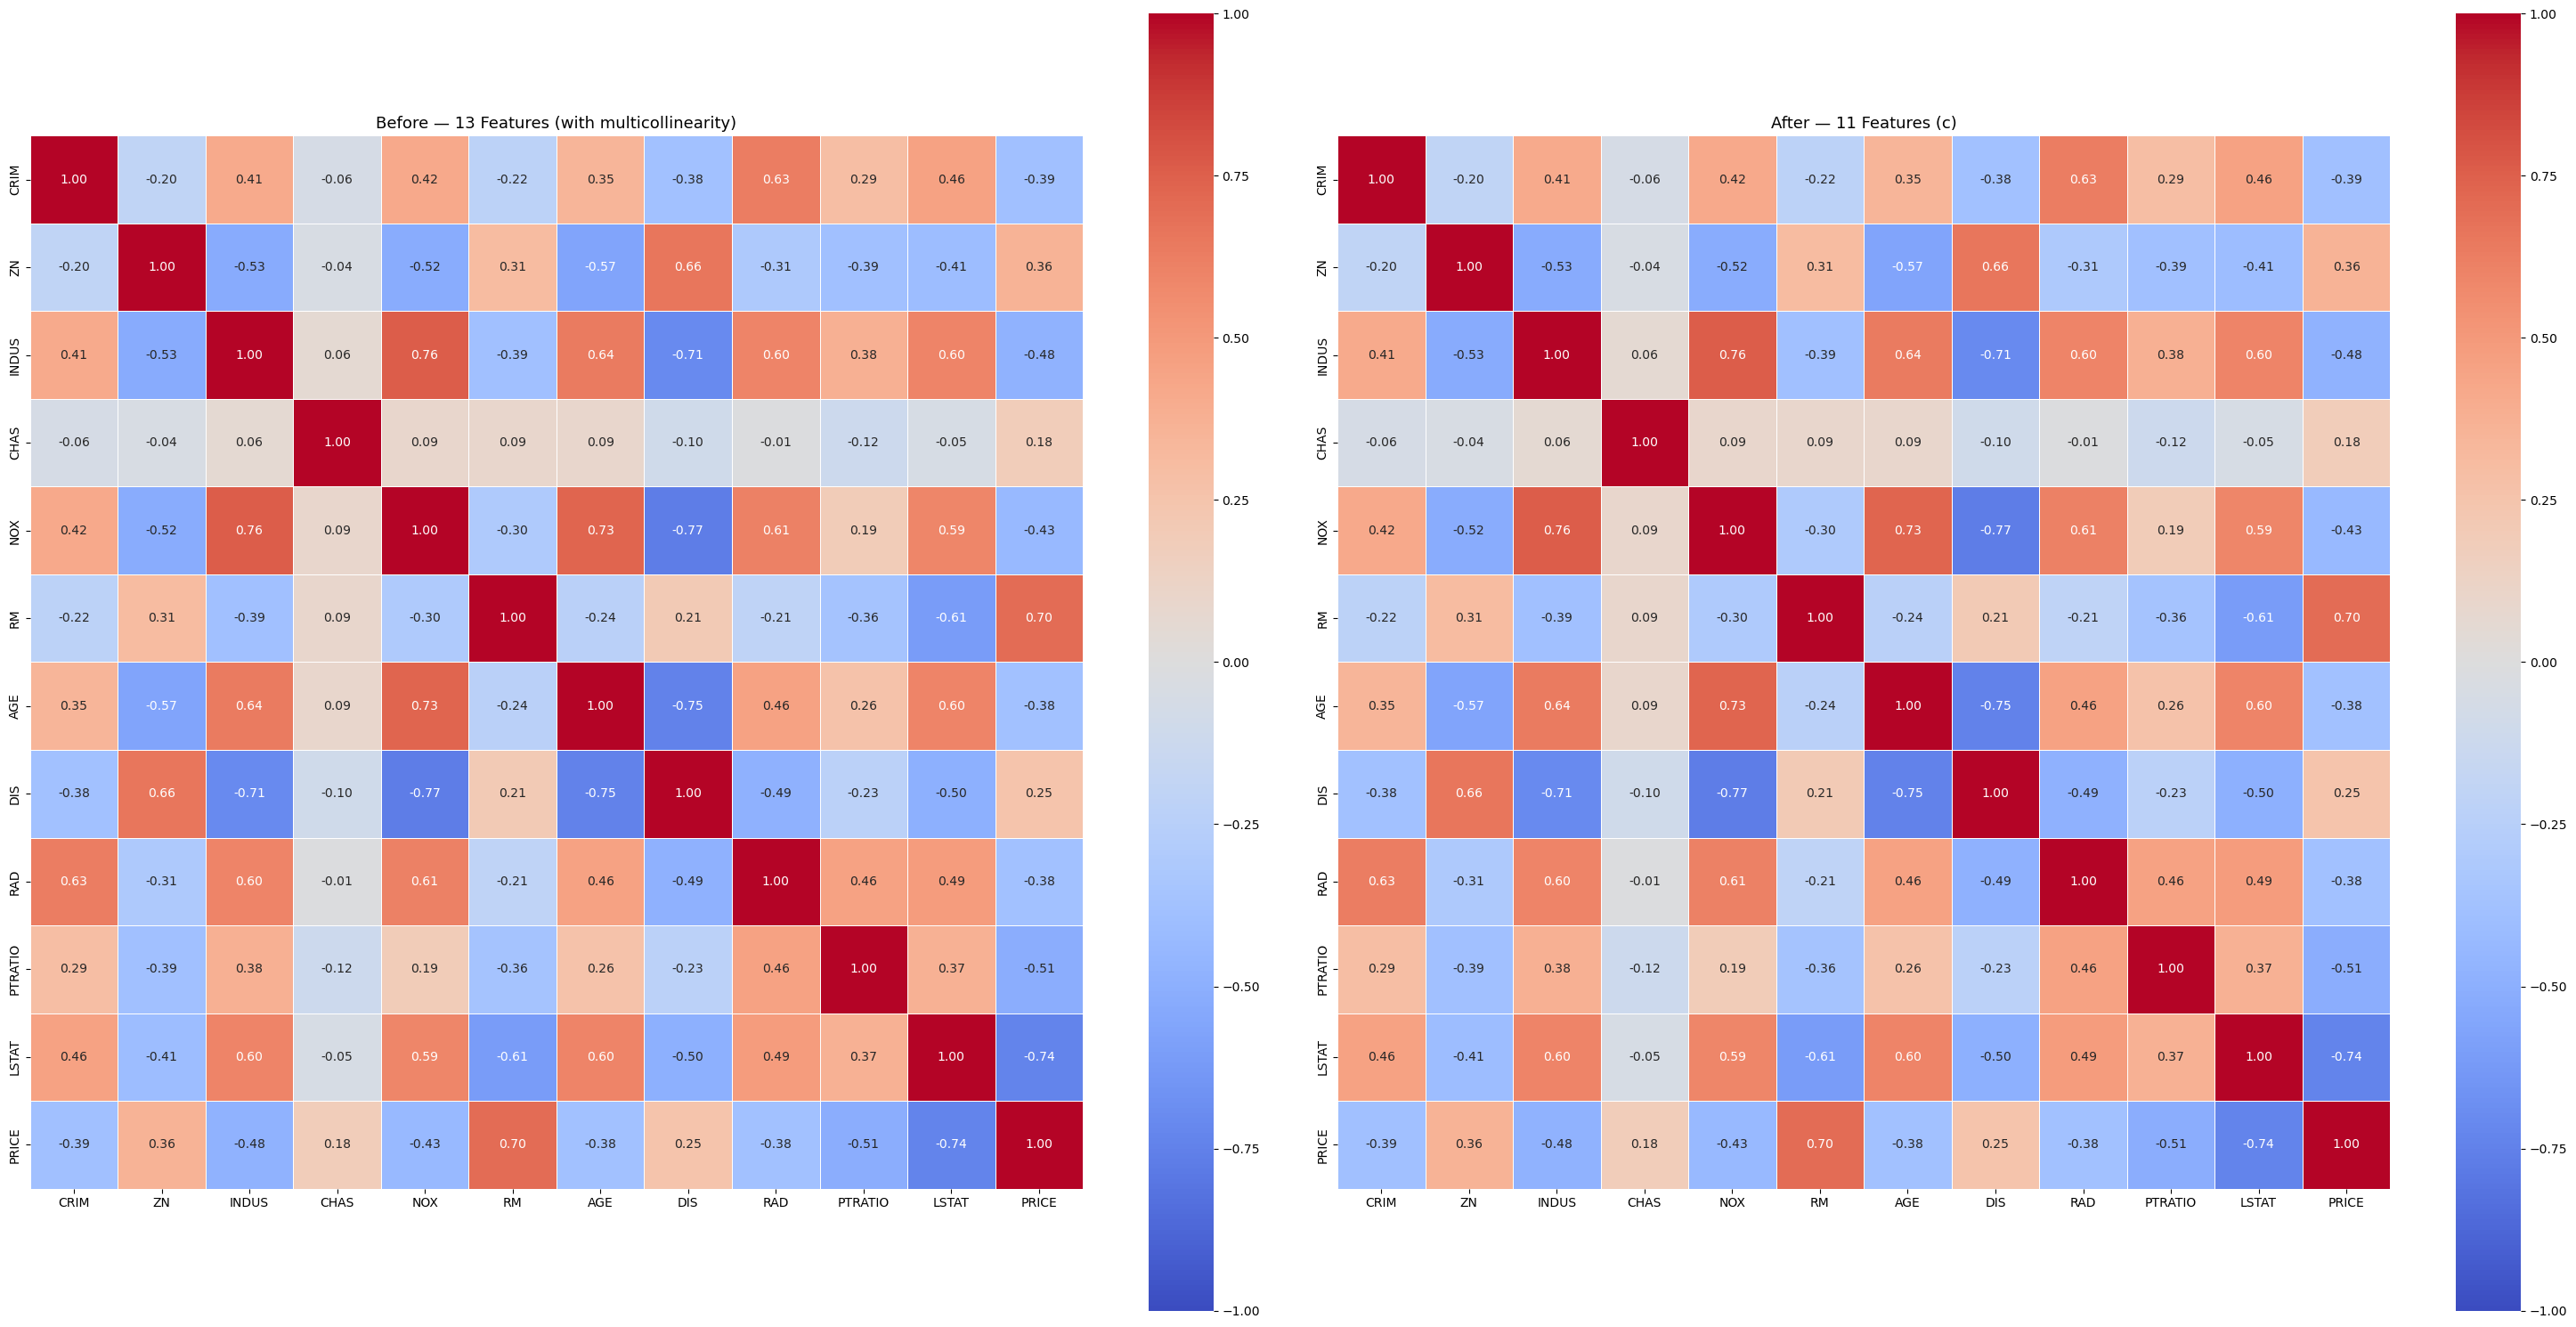

In [325]:
fig, axes = plt.subplots(1, 2, figsize=(30, 15))

# Before
sns.heatmap(
    df.corr().round(2),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=axes[0]
)
axes[0].set_title('Before — 13 Features (with multicollinearity)', fontsize=13)

# After
sns.heatmap(
    df_clean.corr().round(2),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=axes[1]
)
axes[1].set_title('After — 11 Features (c)', fontsize=13)

plt.tight_layout()
plt.show()

## Visualize with Data

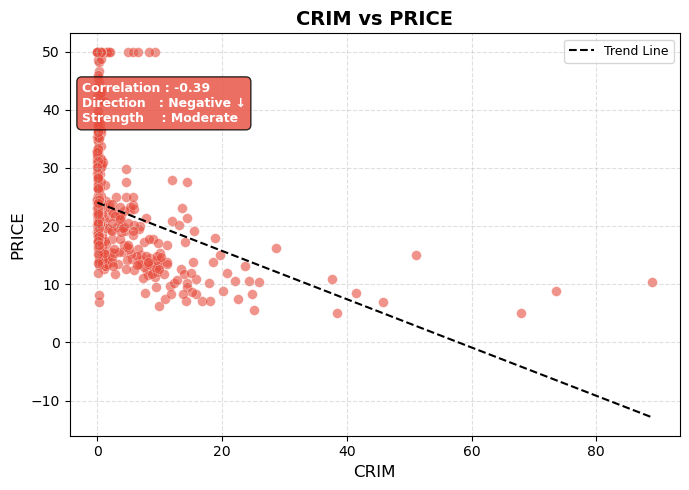

CRIM vs PRICE | r = -0.39 | Moderate Negative
-------------------------------------------------------


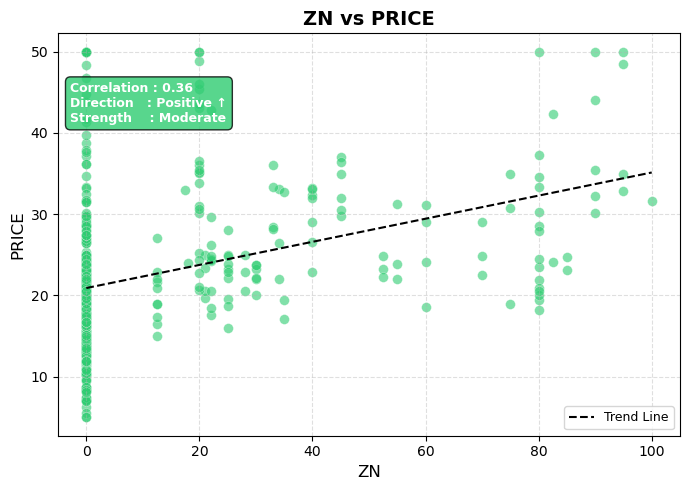

ZN vs PRICE | r = 0.36 | Moderate Positive
-------------------------------------------------------


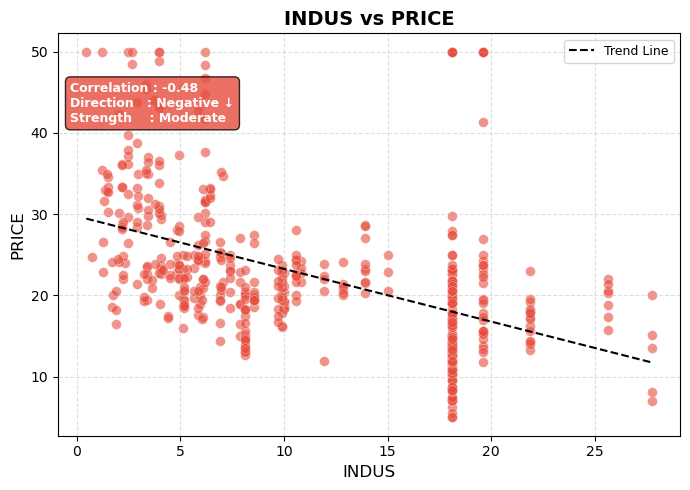

INDUS vs PRICE | r = -0.48 | Moderate Negative
-------------------------------------------------------


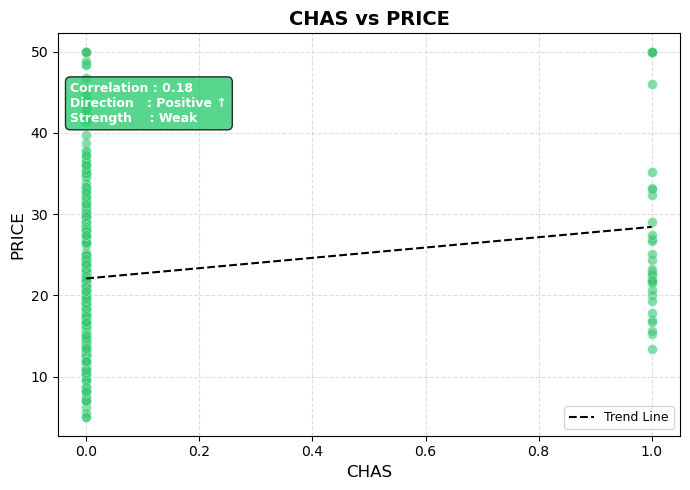

CHAS vs PRICE | r = 0.18 | Weak Positive
-------------------------------------------------------


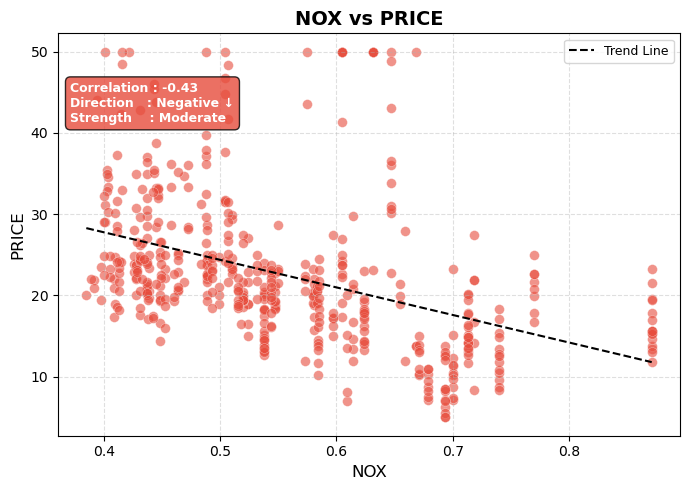

NOX vs PRICE | r = -0.43 | Moderate Negative
-------------------------------------------------------


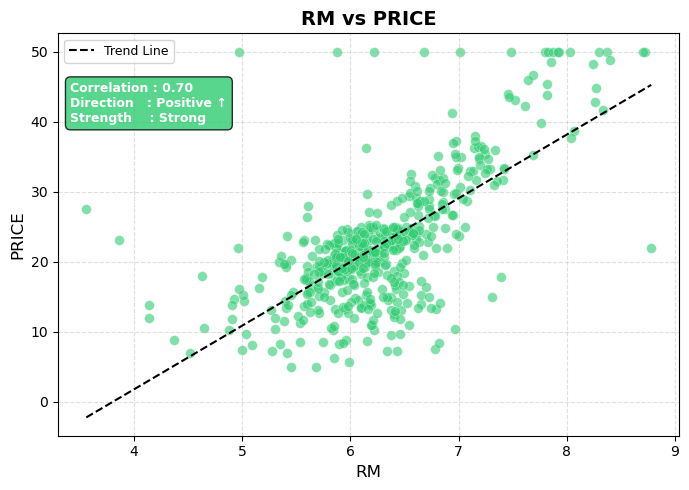

RM vs PRICE | r = 0.70 | Strong Positive
-------------------------------------------------------


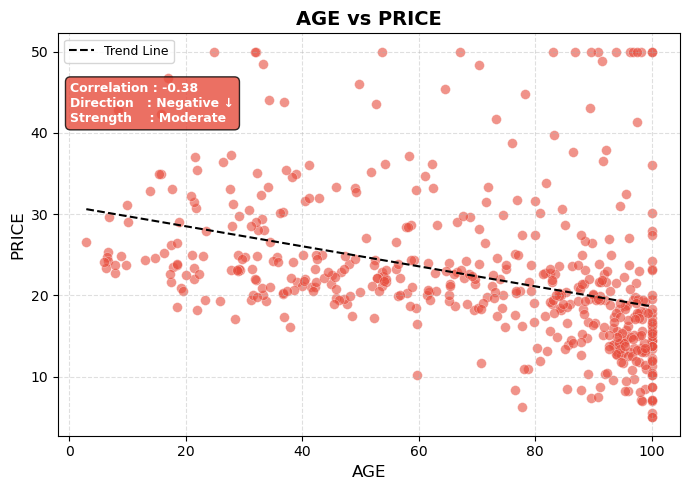

AGE vs PRICE | r = -0.38 | Moderate Negative
-------------------------------------------------------


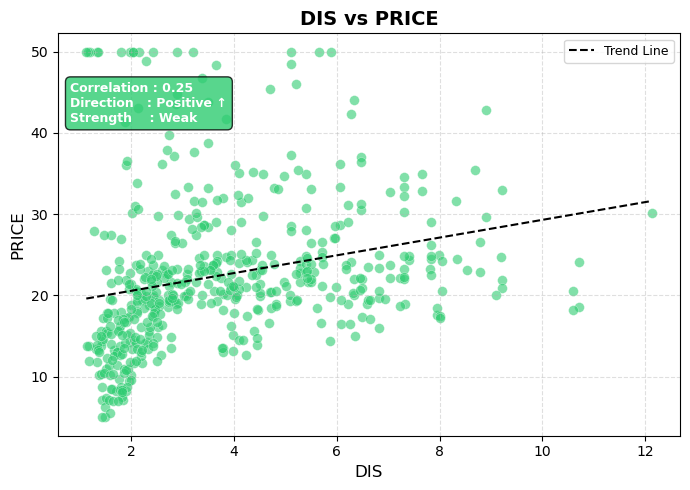

DIS vs PRICE | r = 0.25 | Weak Positive
-------------------------------------------------------


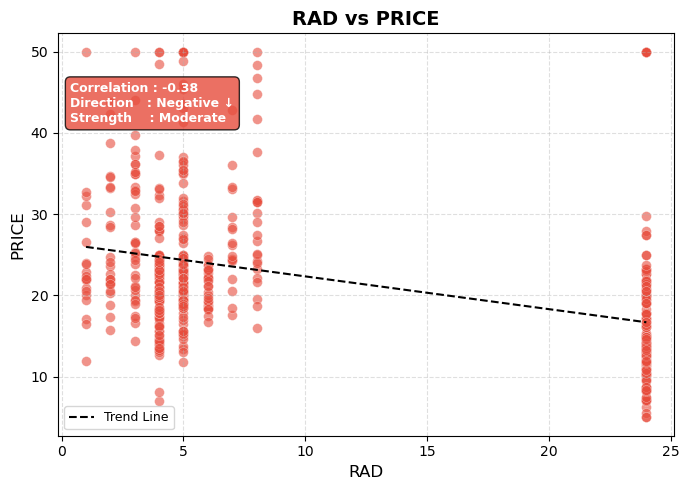

RAD vs PRICE | r = -0.38 | Moderate Negative
-------------------------------------------------------


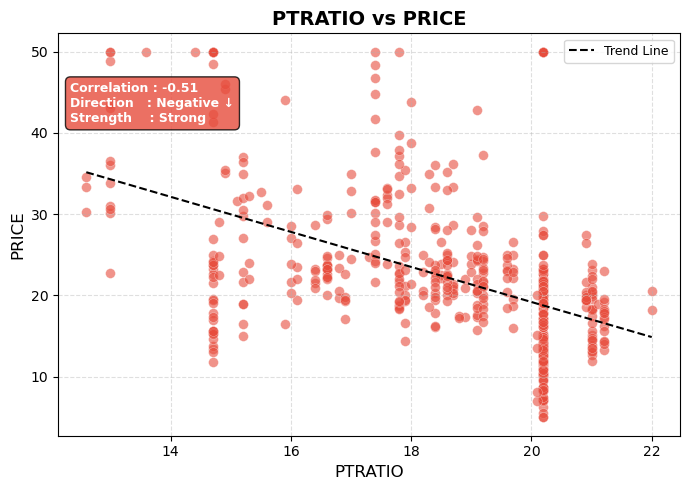

PTRATIO vs PRICE | r = -0.51 | Strong Negative
-------------------------------------------------------


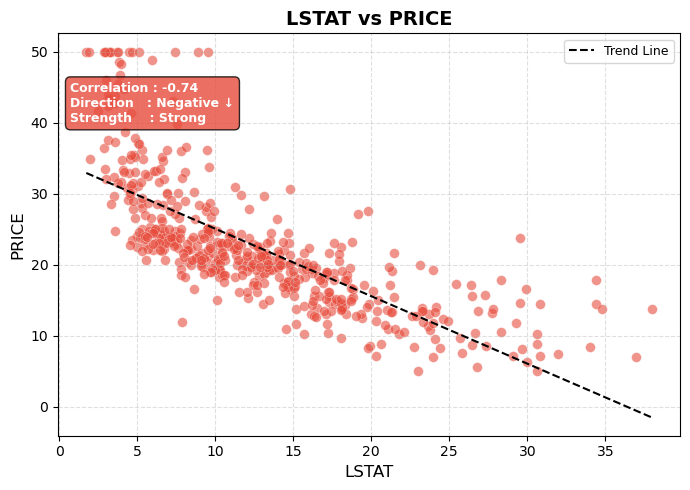

LSTAT vs PRICE | r = -0.74 | Strong Negative
-------------------------------------------------------


In [326]:
# Individual Scatter Plots (Dependent Feature(Price) and Independent Feature(Rest 11 Feature))

features = [col for col in df_clean.columns if col != 'PRICE']

for feature in features:
    fig, ax = plt.subplots(figsize=(7, 5))
    
    corr_val = df_clean[feature].corr(df_clean['PRICE'])
    
    # Color based on correlation
    color = '#2ecc71' if corr_val > 0 else '#e74c3c'
    
    ax.scatter(
        df_clean[feature], df_clean['PRICE'],
        alpha=0.6,
        color=color,
        edgecolors='white',
        linewidths=0.3,
        s=50
    )
    
    # Trend line
    z = np.polyfit(df_clean[feature], df_clean['PRICE'], 1)
    p = np.poly1d(z)
    ax.plot(
        sorted(df_clean[feature]),
        p(sorted(df_clean[feature])),
        color='black',
        linewidth=1.5,
        linestyle='--',
        label='Trend Line'
    )
    
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('PRICE', fontsize=12)
    ax.set_title(f'{feature} vs PRICE', fontsize=14, fontweight='bold')
    
    # Correlation box
    box_color = '#2ecc71' if corr_val > 0 else '#e74c3c'
    ax.annotate(
        f'Correlation : {corr_val:.2f}\n'
        f'Direction   : {"Positive ↑" if corr_val > 0 else "Negative ↓"}\n'
        f'Strength    : {"Strong" if abs(corr_val) > 0.5 else "Moderate" if abs(corr_val) > 0.3 else "Weak"}',
        xy=(0.02, 0.78),
        xycoords='axes fraction',
        fontsize=9,
        color='white',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=box_color, alpha=0.8)
    )
    
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
    
    # Separator
    print(f"{feature} vs PRICE | r = {corr_val:.2f} | "
          f"{'Strong' if abs(corr_val) > 0.5 else 'Moderate' if abs(corr_val) > 0.3 else 'Weak'} "
          f"{'Positive' if corr_val > 0 else 'Negative'}")
    print("-" * 55)

In [327]:
#Strong-0.5 to 1.0(Feature directly impacts Price)
#Moderate-0.3 to 0.5(Feature somewhat impacts Price)
#Weak-0.0 to 0.3(Feature barely impacts Price)



# +1.0  -  Perfect Positive   
# +0.7  -  Strong Positive    
# +0.5  -  Moderate Positive  
# +0.3  -  Weak Positive      
#  0.0  -  Zero               
# -0.3  -  Weak Negative      
# -0.5  -  Moderate Negative  
# -0.7  -  Strong Negative    
# -1.0  -  Perfect Negative

In [328]:
# independent and dependent feature
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,PTRATIO,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,18.7,5.33,36.2


In [329]:
X=df.iloc[:,:-1]
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,PTRATIO,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,15.3,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,17.8,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,17.8,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,18.7,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,18.7,5.33


In [330]:
y=df.iloc[:,-1]
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: PRICE, dtype: float64

In [331]:
print("X Shape (Features) :", X.shape)
print("y Shape (Target)   :", y.shape)

X Shape (Features) : (506, 11)
y Shape (Target)   : (506,)


In [332]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=10)

In [333]:
len(X_train)

354

In [334]:
len(X_test)

152

In [335]:
len(y_train)

354

In [336]:
len(y_test)

152

In [337]:
## standardize the datasets
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [338]:
X_train=scaler.fit_transform(X_train)

In [339]:
X_test=scaler.transform(X_test)

In [340]:
X_train

array([[-0.41649788, -0.47088369, -1.24221453, ..., -0.88420029,
        -0.26207053, -1.24456651],
       [-0.38958849, -0.47088369,  1.49151829, ..., -0.65958105,
         1.22452684, -0.05240584],
       [ 1.41271862, -0.47088369,  0.94621053, ...,  1.58661128,
         0.75996516,  1.69675957],
       ...,
       [-0.1393715 , -0.47088369,  0.94621053, ...,  1.58661128,
         0.75996516,  0.05274301],
       [-0.4105828 , -0.47088369,  2.03250962, ..., -0.88420029,
         0.24894732,  0.26161979],
       [-0.33784409,  0.3618518 , -1.08682341, ..., -0.54727144,
        -2.58487891, -0.35790589]], shape=(354, 11))

In [341]:
X_test

array([[-0.42460396,  0.90312987, -1.34436981, ..., -0.3226522 ,
        -0.07624586, -0.57388732],
       [-0.42864473,  2.02732279, -1.23645931, ..., -0.9965099 ,
        -1.37701855, -1.12805021],
       [-0.42692998,  2.86005828, -1.17315181, ..., -0.65958105,
        -1.14473771, -1.17920371],
       ...,
       [-0.42595416,  2.86005828, -1.17315181, ..., -0.65958105,
        -1.14473771, -0.38774543],
       [ 4.19148213, -0.47088369,  0.94621053, ...,  1.58661128,
         0.75996516,  0.22041281],
       [-0.41981813,  0.04957599, -0.52568877, ..., -0.54727144,
        -1.56284322,  0.38950353]], shape=(152, 11))

## Model Training

In [342]:
from sklearn.linear_model import LinearRegression

In [343]:
regression=LinearRegression()

In [344]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [345]:
## coefficients and the intercepts
print(regression.coef_)

[-1.25685576  1.39927734 -0.86672645  0.52022083 -2.0697107   2.05129689
  0.43294935 -3.40049566  0.79047285 -1.75861643 -4.18717127]


In [346]:
print(regression.intercept_)

21.971186440677965


In [347]:
# coefficients with feature names 
coefficients = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': regression.coef_
}).sort_values('Coefficient', ascending=False)

print(coefficients.to_string(index=False))

Feature  Coefficient
     RM     2.051297
     ZN     1.399277
    RAD     0.790473
   CHAS     0.520221
    AGE     0.432949
  INDUS    -0.866726
   CRIM    -1.256856
PTRATIO    -1.758616
    NOX    -2.069711
    DIS    -3.400496
  LSTAT    -4.187171


In [348]:
# on which parameter the model has been trained
regression.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

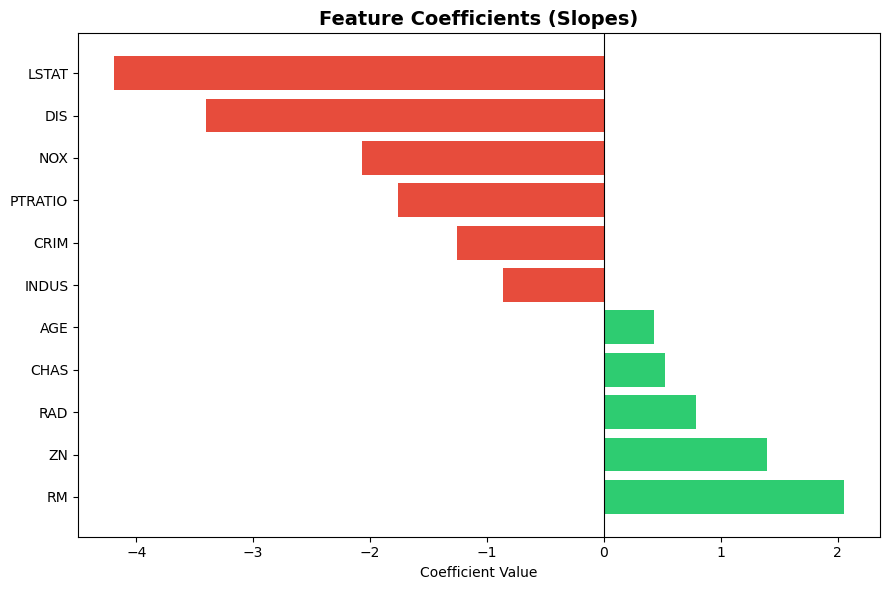

In [349]:
# Visual Bar Plot
plt.figure(figsize=(9, 6))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in coefficients['Coefficient']]

plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients (Slopes)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [350]:
# Meaning

#RM +2.05 (PRICE goes up by 2.05 for every 1 room added)
#LSTAT -4.18  (PRICE goes down by 4.18 for every 1% poor population)

# positive coefficient - Feature Increase Price
# Negative coefficient - Feature Decreases Price

# Big Number - Strong impact on Price (like LSTAT  -4.187171, RM  2.051297)
# Small Number - Weaker impact on Price(like AGE 0.432949)

In [351]:
# prediction with test data
y_pred=regression.predict(X_test)

In [352]:
y_pred

array([30.21670916, 32.28310334, 31.44250695, 23.64159067, 18.83269506,
       18.46606686, 36.10270544, 14.63991386, 24.9612881 , 36.59156272,
       22.26267325, 30.9142685 , 27.65117674, 33.51637143, 33.79498519,
       39.80742039, 23.85638295, 23.09530703, 25.67556123, 21.91609296,
       33.01298836, 17.17323257, 26.54559533, 24.67469705, 33.6586128 ,
       19.52264976, 18.80750629, 16.89469766, 38.3634323 ,  3.54880053,
       33.58318872, 31.86836638, 26.36814809, 23.23599502, 19.1280697 ,
       19.92785189,  5.40164816, 34.3257297 , 26.9964075 , 28.36353828,
       33.71501733, 29.29474072, 16.94574254, 32.20652134, 17.18361515,
       29.03196132, 18.44126888, 20.68091095, 37.26552379, 16.26949363,
       24.35360625, 17.95991041, 24.1551686 , 34.92436942, 26.67726074,
       34.07638588, 21.9565571 , 18.35824066, 19.18095405, 23.15911096,
       19.90503708, 24.41971245, 39.86461859, 41.91546125, 30.59684178,
       16.74919669, 23.82066953,  2.99132906, 31.29361002, 27.81

## Assumptions

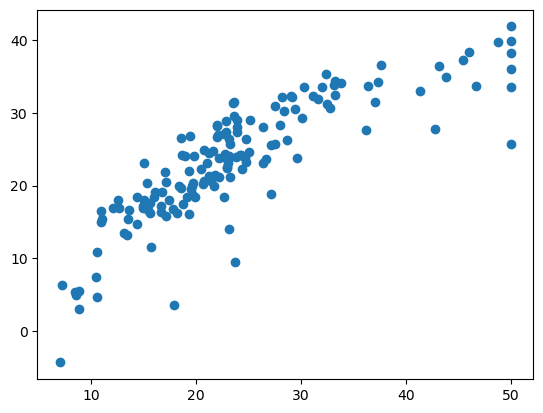

In [353]:
## plot a scatter plot for the prediction
plt.scatter(y_test,y_pred)

In [354]:
# Prediction with residuals
residuals=y_test-y_pred

In [355]:
residuals

305   -1.816709
193   -1.183103
65    -7.942507
349    2.958409
151    0.767305
         ...   
56    -1.762565
37    -2.085027
66    -7.387674
427   -4.100140
12     1.788753
Name: PRICE, Length: 152, dtype: float64

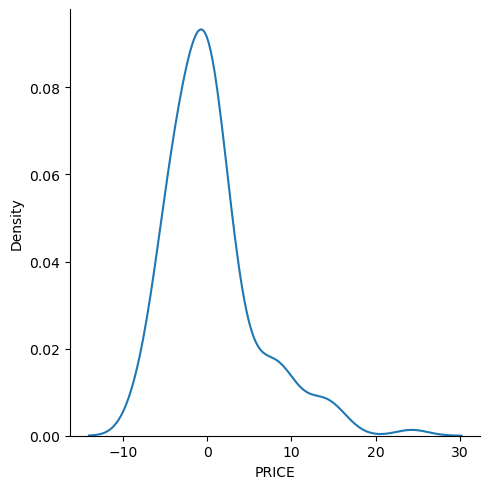

In [356]:
## plot with residuals
sns.displot(residuals,kind='kde')

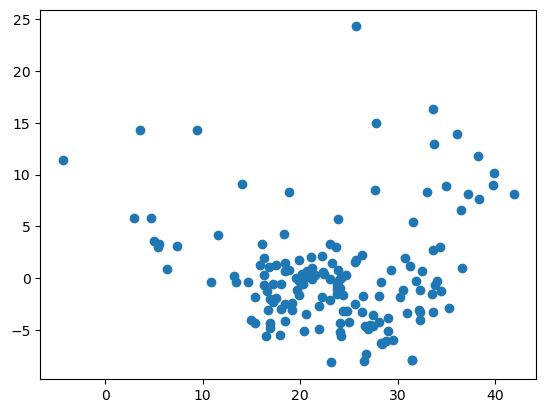

In [357]:
## scatter plot with respect to predictions and residuals
# uniform distribution
plt.scatter(y_pred,residuals)

### Performance Metrics

In [358]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [359]:
# Performance Regression Metrics
print("Mean Squared Error =",mean_squared_error(y_test,y_pred))
print("Mean Absolute Error =",mean_absolute_error(y_test,y_pred))
print("Root Mean Squared Error =",np.sqrt(mean_squared_error(y_test,y_pred)))

Mean Squared Error = 28.67231288343395
Mean Absolute Error = 3.7609885403505574
Root Mean Squared Error = 5.3546533859283505


In [360]:
# r square and adjusted R Square
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print("R-squared",score)

R-squared 0.7063270051738882


In [361]:
## adjusted R Squared
print("Adjusted R-squared",1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

Adjusted R-squared 0.6832526984375509


## New Data Prediction

In [362]:
input_df = pd.DataFrame(
    [df_clean.drop(columns=['PRICE']).iloc[0]],
    columns=['CRIM','ZN','INDUS','CHAS','NOX',
             'RM','AGE','DIS','RAD','PTRATIO','LSTAT']
)
input_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,PTRATIO,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.09,1.0,15.3,4.98


In [363]:
scaler.transform(input_df)

array([[-0.43055341,  0.27857825, -1.32566533, -0.24470439, -0.16542775,
         0.48012722, -0.1390934 ,  0.14327903, -0.9965099 , -1.51638705,
        -1.13515486]])

In [364]:
# #tranformation of new data
regression.predict(scaler.transform(input_df))

array([31.335775])

## pickling The Model File for Deployment

In [371]:
import pickle

In [372]:
pickle.dump(regression,open("regmodel.pkl","wb")) #dump-save object (Serialization=pickling)

In [373]:
pickle.dump(scaler,open("scaler.pkl","wb"))

In [374]:
picked_model=pickle.load(open("regmodel.pkl","rb"))
# load - picked_model already knows trained weights (deserialization=Unpickling)

In [375]:
scaler = pickle.load(open("scaler.pkl","rb"))

In [376]:
picked_model.predict(scaler.transform(input_df))

array([31.335775])